# Task 5: Mental Health Support Chatbot (Fine-Tuned DistilGPT2)

**DevelopersHub Corporation — AI/ML Engineering Internship**

## What we're building
We'll take DistilGPT2 — a small language model (82 million parameters) — and fine-tune it on the **EmpatheticDialogues** dataset. This will teach the model to respond empathetically when someone talks about stress, anxiety, sadness, or daily struggles.

## Why this matters
Mental health support should be accessible. While AI can't replace a therapist, it can provide a **non-judgmental listening ear** 24/7. This project shows how fine-tuning transforms a general-purpose model into a domain-specific helper.

## Notebook roadmap
| Step | What happens |
|------|-------------|
| 1-2 | Install deps + import libraries |
| 3 | Load & explore the dataset — understand our data |
| 4 | Visualize dataset — see emotion patterns & conversation lengths |
| 5 | Format data for training — turn conversations into model-friendly text |
| 6 | Load base DistilGPT2 model |
| 7 | Configure training (learning rate, batch size, epochs) |
| 8 | Train the model (GPU recommended) |
| 9 | Plot training progress — watch the loss go down |
| 10 | Save the fine-tuned model |
| 11 | Test the model with sample conversations |
| 12 | Interactive chat (runs in Colab terminal) |
| 13 | Summary + next steps |

## 1. Install Additional Dependencies

We need two extra packages not in the default Colab environment:

- **`kagglehub`** — downloads the EmpatheticDialogues dataset from Kaggle
- **`matplotlib`** — creates charts to visualize our data

In [1]:
# Install packages needed for this notebook
!pip install -q kagglehub matplotlib

## 2. Import Libraries

Each library has a specific job:

| Library | Purpose |
|---------|---------|
| `torch` | PyTorch — the deep learning engine that runs the model |
| `transformers` | Hugging Face library — gives us DistilGPT2, tokenizer, and training tools |
| `datasets` | Hugging Face datasets — loads and manipulates our data |
| `pandas` / `numpy` | Data handling and math |
| `matplotlib` | Creates charts (emotion distribution, training curves) |
| `kagglehub` | Downloads the EmpatheticDialogues dataset |
| `IPython.display` | Renders nice HTML outputs in the notebook |

In [2]:
import torch
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from transformers import (
    AutoTokenizer, AutoModelForCausalLM,
    Trainer, TrainingArguments,
    pipeline, DataCollatorForLanguageModeling
)
from datasets import load_dataset, DatasetDict
import kagglehub
from IPython.display import display, HTML

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print("Training will be ~10x faster on GPU!")
else:
    print("Running on CPU. Consider enabling GPU: Runtime > Change runtime type > T4 GPU")

All imports successful!
PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Training will be ~10x faster on GPU!


## 3. Load the EmpatheticDialogues Dataset

### What is this dataset?
Created by Facebook AI Research (now Meta AI), **EmpatheticDialogues** contains **25,000+ conversations** grounded in specific emotions. Each conversation has:

- **Situation** — the context (e.g., "I just found out I got the job!")
- **empathetic_dialogues** — what the person said
- **labels** — the response
- **emotion** — the emotional category (from 32 emotions like "sad", "joyful", "anxious")

### How we load it
We use `kagglehub` to download the Kaggle-hosted version, then split into:
- **80% training** — the model learns from these examples
- **10% validation** — we check progress without memorizing
- **10% test** — final evaluation after training

In [3]:
import os
from datasets import load_dataset

print("Downloading EmpatheticDialogues from Kaggle...")
path = kagglehub.dataset_download("atharvjairath/empathetic-dialogues-facebook-ai")
csv_path = os.path.join(path, "emotion-emotion_69k.csv")

# Load the full dataset as a single split
full_dataset = load_dataset("csv", data_files=csv_path, split="train")

# Split into train (80%), validation (10%), test (10%)
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
test_val_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)

dataset = DatasetDict({
    'train': train_test_split['train'],
    'validation': test_val_split['train'],
    'test': test_val_split['test']
})

print(f"\nDataset splits: {dataset.keys()}")
print(f"Train size: {len(dataset['train']):,}")
print(f"Validation size: {len(dataset['validation']):,}")
print(f"Test size: {len(dataset['test']):,}")

100%|██████████| 3.26M/3.26M [00:00<00:00, 91.3MB/s]

Extracting files...


Generating train split: 0 examples [00:00, ? examples/s]


Dataset splits: dict_keys(['train', 'validation', 'test'])
Train size: 51,708
Validation size: 6,464
Test size: 6,464


In [4]:
# Look at dataset column names and a few examples
print("Column names:", dataset['train'].features)
print()

# Show 3 examples so we understand the data structure
for i in range(3):
    example = dataset['train'][i]
    print(f"--- Example {i+1} ---")
    print(f"Emotion:  {example['emotion']}")
    print(f"Situation: {example['Situation']}")
    print(f"User says: {example['empathetic_dialogues']}")
    print(f"Response:  {example['labels']}")
    print()

Column names: {'Unnamed: 0': Value('int64'), 'Situation': Value('string'), 'emotion': Value('string'), 'empathetic_dialogues': Value('string'), 'labels': Value('string'), 'Unnamed: 5': Value('string'), 'Unnamed: 6': Value('string')}

--- Example 1 ---
Emotion:  impressed
Situation: I recently took a trip to Canada and was pleasantly surprised by how friendly the people were there.
User says: Customer :Wow, I didn't know that! Did you have a good time?
Agent :
Response:  It was a very pleasant surprise to me too! I had a wonderful time, the customer service was completely outstanding!

--- Example 2 ---
Emotion:  grateful
Situation: I was walking along today and suddenly someone stopped me. They prevented me from stepping in a hole.
User says: Customer :Oh, really? What happened to you?
Agent :
Response:  I almost stepped into a big hole! But luckily someone stopped me from walking!

--- Example 3 ---
Emotion:  afraid
Situation: I found a copperhead in my backyard.
User says: Customer :

## 4. Visualize the Dataset

Before we train, let's understand our data visually.

### What to look for
1. **Emotion distribution** — are some emotions over/under-represented? If "joyful" has 10x more examples than "angry", the model will be better at joyful replies.
2. **Conversation length** — how many words per example? Short conversations are easier to learn from. Very long ones may be truncated.
3. **Emotion-to-response patterns** — does the model need to learn that "sad" situations need gentle, supportive language?

### Expected output
- A **bar chart** showing the count of each emotion
- A **histogram** showing the distribution of conversation lengths

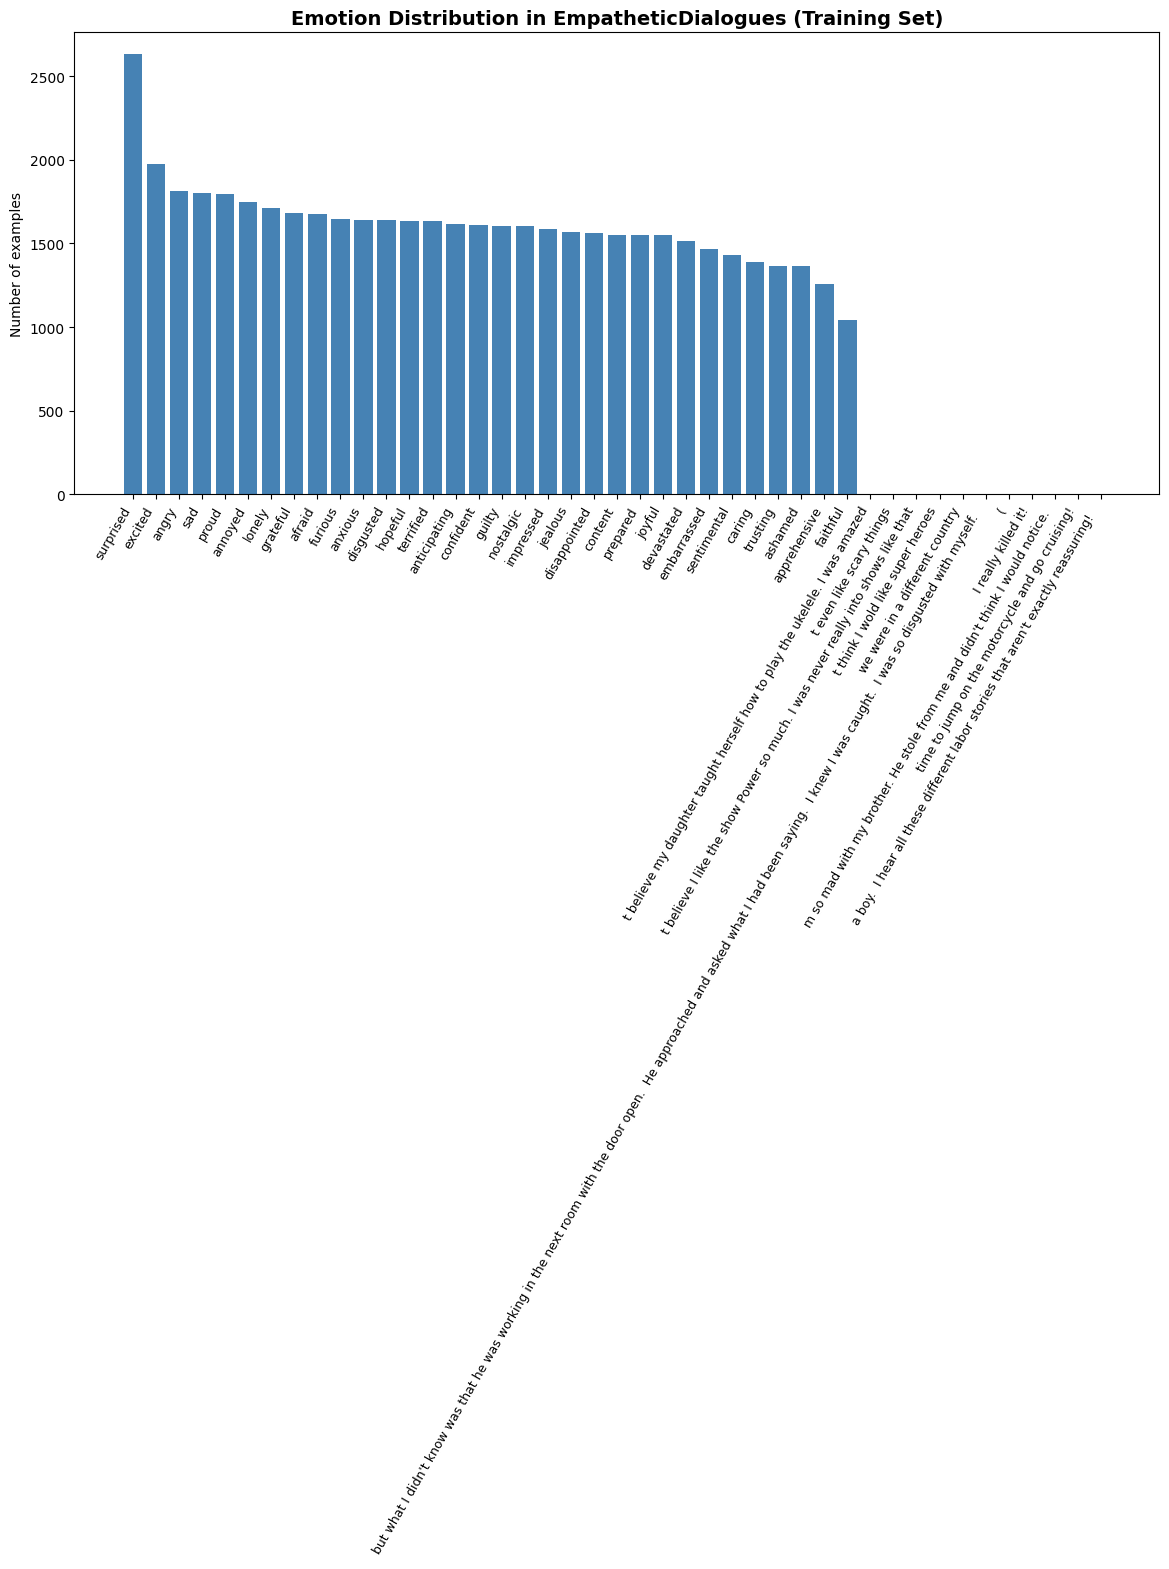


Top 5 most common emotions:
  surprised: 2,631 examples
  excited: 1,973 examples
  angry: 1,816 examples
  sad: 1,803 examples
  proud: 1,797 examples

Bottom 5 rarest emotions:
  (: 3 examples
   I really killed it!: 3 examples
  m so mad with my brother. He stole from me and didn't think I would notice. : 2 examples
   time to jump on the motorcycle and go cruising!: 2 examples
   a boy.  I hear all these different labor stories that aren't exactly reassuring!  : 2 examples


In [5]:
# --- Chart 1: Emotion Distribution ---
emotions = [dataset['train'][i]['emotion'] for i in range(len(dataset['train']))]
emotion_counts = pd.Series(emotions).value_counts()

plt.figure(figsize=(14, 6))
bars = plt.bar(range(len(emotion_counts)), emotion_counts.values, color='steelblue')
plt.xticks(range(len(emotion_counts)), emotion_counts.index, rotation=60, ha='right', fontsize=9)
plt.ylabel('Number of examples')
plt.title('Emotion Distribution in EmpatheticDialogues (Training Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTop 5 most common emotions:")
for emo, cnt in emotion_counts.head(5).items():
    print(f"  {emo}: {cnt:,} examples")
print(f"\nBottom 5 rarest emotions:")
for emo, cnt in emotion_counts.tail(5).items():
    print(f"  {emo}: {cnt:,} examples")

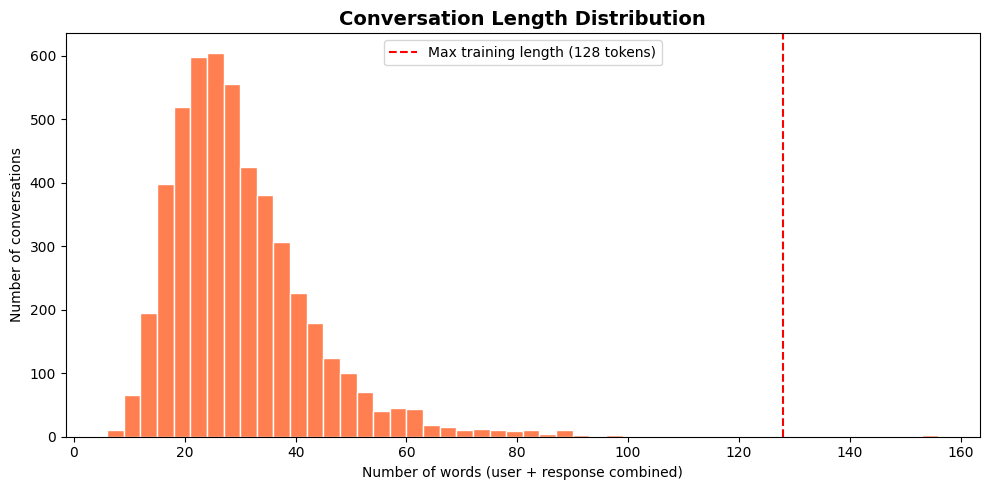

Average length: 30 words
Median length:  27 words
Max length:     156 words

(Red dashed line = where we'll truncate — most examples fit comfortably)


In [6]:
# --- Chart 2: Conversation Length Distribution ---
lengths = []
for i in range(min(5000, len(dataset['train']))):
    text = f"{dataset['train'][i]['empathetic_dialogues']} {dataset['train'][i]['labels']}"
    lengths.append(len(text.split()))

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color='coral', edgecolor='white')
plt.xlabel('Number of words (user + response combined)')
plt.ylabel('Number of conversations')
plt.title('Conversation Length Distribution', fontsize=14, fontweight='bold')
plt.axvline(x=128, color='red', linestyle='--', label='Max training length (128 tokens)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Average length: {np.mean(lengths):.0f} words")
print(f"Median length:  {np.median(lengths):.0f} words")
print(f"Max length:     {max(lengths)} words")
print("\n(Red dashed line = where we'll truncate — most examples fit comfortably)")

## 5. Format Conversations for Training

### How language models learn
GPT-style models are **causal language models** — they predict the next word given the previous words. So to train our chatbot:

1. We format each example as one continuous string: `Context: ... User message ... Response: ...`
2. The model reads the entire string and learns to predict every word
3. During testing, we give it `Context: User message Response:` and it generates the next words

### What we do
- Load the **DistilGPT2 tokenizer** (converts text to numbers the model understands)
- Write a `format_conversation()` function that turns each row into a training string
- Apply this to the entire dataset

In [7]:
MODEL_NAME = "distilgpt2"  # 82M parameters — small, fast, good for experimentation

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no pad token, so we reuse EOS
tokenizer.padding_side = "left"  # Left-padding for text generation

print(f"Model: {MODEL_NAME}")
print(f"Vocabulary size: {tokenizer.vocab_size:,} unique tokens")
print(f"Max context length: {tokenizer.model_max_length} tokens")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Model: distilgpt2
Vocabulary size: 50,257 unique tokens
Max context length: 1024 tokens


In [9]:
def format_conversation(example):
    """Turn a dataset row into a training string for causal LM."""
    situation = example.get('Situation', '')
    context = example.get('empathetic_dialogues', '')
    response = example.get('labels', '')

    # The model learns: given the context (situation + what user said), predict the response
    full_text = f"""Context: {situation}
{context}{response}{tokenizer.eos_token}"""
    return {"text": full_text}

# Apply formatting to train and validation sets
train_data = dataset['train'].map(format_conversation, remove_columns=dataset['train'].column_names)
val_data = dataset['validation'].map(format_conversation, remove_columns=dataset['validation'].column_names)

print(f"Training samples formatted: {len(train_data):,}")
print(f"Validation samples formatted: {len(val_data):,}")
print(f"\nExample formatted text:\n{train_data[0]['text']}")

Map:   0%|          | 0/51708 [00:00<?, ? examples/s]

Map:   0%|          | 0/6464 [00:00<?, ? examples/s]

Training samples formatted: 51,708
Validation samples formatted: 6,464

Example formatted text:
Context: I recently took a trip to Canada and was pleasantly surprised by how friendly the people were there.
Customer :Wow, I didn't know that! Did you have a good time?
Agent :It was a very pleasant surprise to me too! I had a wonderful time, the customer service was completely outstanding!<|endoftext|>


In [11]:
def tokenize_function(examples):
    """Convert text into token IDs the model can process."""
    return tokenizer(
        examples['text'],
        truncation=True,        # Cut off examples longer than max_length
        padding='max_length',   # Pad shorter examples to same length
        max_length=128          # Keep this reasonable for GPU memory
    )

print("Tokenizing dataset — this converts words to numbers...")
tokenized_train = train_data.map(tokenize_function, batched=True, remove_columns=['text'])
tokenized_val = val_data.map(tokenize_function, batched=True, remove_columns=['text'])

print(f"Tokenized train samples: {len(tokenized_train):,}")
print(f"Tokenized validation samples: {len(tokenized_val):,}")
print(f"Each sample is now a vector of {len(tokenized_train[0]['input_ids'])} integers")

Tokenizing dataset — this converts words to numbers...


Map:   0%|          | 0/51708 [00:00<?, ? examples/s]

Tokenized train samples: 51,708
Tokenized validation samples: 6,464
Each sample is now a vector of 128 integers


## 6. Load Base DistilGPT2 Model

### What is DistilGPT2?
- **Distilled version** of GPT-2 (hence "Distil") — 82M parameters vs GPT-2's 124M
- Trained to mimic GPT-2 but runs **40% faster** and uses **30% less memory**
- Perfect for experimentation and CPU-friendly deployment

### What happens here
We load the pre-trained model. At this point, it knows English grammar and general knowledge, but NOT how to be empathetic. That's what fine-tuning will teach it.

In [12]:
print(f"Loading {MODEL_NAME}...")
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} (all are trainable -- full fine-tuning)")
print(f"Architecture: {model.config.architectures[0]}")
print("\nModel loaded and ready for fine-tuning!")

Loading distilgpt2...


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Total parameters: 81,912,576
Trainable parameters: 81,912,576 (all are trainable -- full fine-tuning)
Architecture: GPT2LMHeadModel

Model loaded and ready for fine-tuning!


## 7. Configure Training

### Key settings explained

| Setting | Value | Why? |
|---------|-------|------|
| **Epochs** | 3 | One epoch = one full pass through all training data. 3 is a good starting point. |
| **Batch size** | 8 | How many examples the model sees at once. Smaller = less memory, slower. |
| **Learning rate** | 5e-5 (0.00005) | How big each training step adjusts the model. Too high = unstable, too low = slow. |
| **Warmup steps** | 500 | Gradually increase learning rate at start — prevents early instability. |
| **Mixed precision (fp16)** | Auto | Uses half-precision on GPU — trains faster with same quality. |

### What is a Data Collator?
It automatically creates training batches by padding shorter sequences to the same length. `mlm=False` means we're doing **causal** (not masked) language modeling — the standard for GPT-style models.

In [17]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False  # Causal LM (predict next word), not masked LM (fill in blanks)
)

training_args = TrainingArguments(
    output_dir="./mental-health-chatbot",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,
    save_strategy="epoch",
    learning_rate=5e-5,
    warmup_steps=500,
    logging_steps=100,
    report_to="none",
    fp16=torch.cuda.is_available(),
    remove_unused_columns=False,
)

print("Training configuration:")
print(f"  Epochs:           {training_args.num_train_epochs}")
print(f"  Batch size:       {training_args.per_device_train_batch_size}")
print(f"  Grad accum steps: {training_args.gradient_accumulation_steps}")
print(f"  Effective batch:  {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Learning rate:    {training_args.learning_rate}")
print(f"  Warmup steps:     {training_args.warmup_steps}")
print(f"  Mixed precision:  {training_args.fp16}")

Training configuration:
  Epochs:           3
  Batch size:       8
  Grad accum steps: 2
  Effective batch:  16
  Learning rate:    5e-05
  Warmup steps:     500
  Mixed precision:  True


In [18]:
# Use a subset for fast demonstration (change to False for full training)
USE_SUBSET = True
SUBSET_SIZE = 5000

if USE_SUBSET:
    train_subset = tokenized_train.select(range(min(SUBSET_SIZE, len(tokenized_train))))
    val_subset = tokenized_val.select(range(min(1000, len(tokenized_val))))
    print(f"Using {len(train_subset):,} training samples + {len(val_subset):,} validation samples")
    print("(Set USE_SUBSET = False above to train on the full dataset)")
else:
    train_subset = tokenized_train
    val_subset = tokenized_val
    print(f"Using FULL dataset: {len(train_subset):,} training samples")

Using 5,000 training samples + 1,000 validation samples
(Set USE_SUBSET = False above to train on the full dataset)


## 8. Train the Model

### What happens during training
1. The model receives a batch of conversation examples
2. It predicts the next token at each position
3. The loss (error) measures how wrong its predictions were
4. Gradients flow backward through the network
5. Weights are updated slightly to reduce the error next time
6. Repeat steps 1-5 thousands of times

### Custom callback
We add a **LossHistoryCallback** to record the loss after every logging step. We'll use this data to plot the learning curve after training.

### Expected output
- A progress bar showing training status
- Periodic loss values printed every 100 steps
- Lower loss = better predictions

### ⏱ Time estimate (subset, 5000 samples)
- **GPU (T4)**: ~5-10 minutes
- **CPU**: ~45-60 minutes

In [20]:
from transformers import TrainerCallback

class LossHistoryCallback(TrainerCallback):
    """Records training and evaluation loss after each logging step."""
    def __init__(self):
        self.train_losses = []
        self.eval_losses = []
        self.steps = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_losses.append(logs["loss"])
            self.steps.append(state.global_step)
        if "eval_loss" in logs:
            self.eval_losses.append(logs["eval_loss"])

loss_tracker = LossHistoryCallback()

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=val_subset,
    data_collator=data_collator,
    callbacks=[loss_tracker],
)

print(f"Starting fine-tuning on {len(train_subset):,} samples...")
print("Each epoch = one full pass through the data")
print("=" * 55)
trainer.train()
print("=" * 55)
print("Fine-tuning complete!")

Starting fine-tuning on 5,000 samples...
Each epoch = one full pass through the data


[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
100,6.172432
200,3.697288
300,3.255647
400,2.978252
500,2.906955
600,2.884547
700,2.786082
800,2.749433
900,2.719337


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Fine-tuning complete!


## 9. Training Progress — Loss Curve

### What are we looking at?
The **loss** measures how surprised the model is by the actual next word. A loss of:

- **~4.0** → model is guessing randomly (baseline)
- **~2.5** → model has learned patterns but still makes mistakes
- **~1.5** → model is confident in its predictions

### Expected shape
A well-trained model's loss curve should:
1. **Start high** (~4.0+) — model hasn't learned anything yet
2. **Drop quickly** in the first few hundred steps — rapid initial learning
3. **Level off** — model is approaching its best performance for this architecture/dataset
4. **Validation loss** (dots) should closely follow training loss (line) — if they diverge, the model is overfitting (memorizing instead of learning)

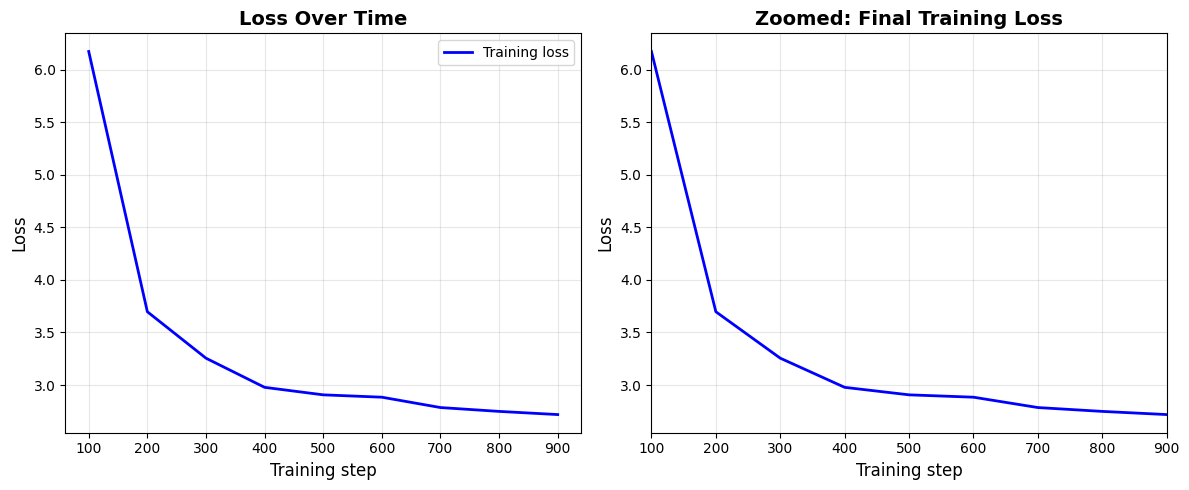

Starting loss:  6.1724
Final loss:     2.7193
Improvement:    3.4531 (55.9% reduction)


In [21]:
if loss_tracker.train_losses:
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(loss_tracker.steps, loss_tracker.train_losses, 'b-', label='Training loss', linewidth=2)
    if loss_tracker.eval_losses:
        eval_steps = [loss_tracker.steps[i] for i in
                     range(0, len(loss_tracker.steps),
                           max(1, len(loss_tracker.steps) // len(loss_tracker.eval_losses)))]
        plt.plot(eval_steps[:len(loss_tracker.eval_losses)],
                 loss_tracker.eval_losses, 'ro-', label='Validation loss')
    plt.xlabel('Training step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Loss Over Time', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(loss_tracker.steps, loss_tracker.train_losses, 'b-', linewidth=2)
    plt.xlabel('Training step', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.title('Zoomed: Final Training Loss', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    if len(loss_tracker.train_losses) > 5:
        plt.xlim([loss_tracker.steps[max(0, len(loss_tracker.steps)-20)],
                  loss_tracker.steps[-1]+1])

    plt.tight_layout()
    plt.show()

    print(f"Starting loss:  {loss_tracker.train_losses[0]:.4f}")
    print(f"Final loss:     {loss_tracker.train_losses[-1]:.4f}")
    print(f"Improvement:    {loss_tracker.train_losses[0] - loss_tracker.train_losses[-1]:.4f} ({((1 - loss_tracker.train_losses[-1]/loss_tracker.train_losses[0])*100):.1f}% reduction)")
else:
    print("No loss data recorded (training may have been skipped or interrupted).")

## 10. Save the Fine-Tuned Model

We save the model and tokenizer to `./mental-health-chatbot-final/`. This directory is what `app.py` (the Streamlit web app) expects to find when serving the chatbot.

### What gets saved
- `pytorch_model.bin` — the learned weights (82M parameters)
- `config.json` — model architecture settings
- `vocab.json` + `merges.txt` — tokenizer files

In [22]:
model_save_path = "./mental-health-chatbot-final"

trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

import os
files = os.listdir(model_save_path)
print(f"Model saved to: {model_save_path}")
print(f"Files: {files}")
print(f"\nTotal size: {sum(os.path.getsize(os.path.join(model_save_path, f)) for f in files) / 1024 / 1024:.1f} MB")

print("\nTo run the web app, execute: streamlit run app.py")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./mental-health-chatbot-final
Files: ['tokenizer.json', 'tokenizer_config.json', 'generation_config.json', 'config.json', 'model.safetensors', 'training_args.bin']

Total size: 315.9 MB

To run the web app, execute: streamlit run app.py


## 11. Test the Fine-Tuned Model

Now the exciting part — let's see what our model learned! We'll:

1. Create a **text generation pipeline** — a ready-to-use interface for the model
2. Write a `get_empathetic_response()` function that:
   - Formats the user's message properly
   - Generates a response with controlled randomness (`temperature=0.7` means creative but coherent)
   - Cleans up the output (removes trailing dataset artifacts)
3. Try it with example queries about anxiety, stress, and sadness

### Expected output
The model should respond with **supportive, context-aware** text. It won't be perfect (it's a small model trained on a subset), but it should show clear signs of learning empathetic patterns.

In [23]:
# Create text generation pipeline
device = 0 if torch.cuda.is_available() else -1
chatbot = pipeline(
    'text-generation',
    model=model,
    tokenizer=tokenizer,
    device=device
)

print(f"Pipeline ready — using {'GPU' if device == 0 else 'CPU'}")

Pipeline ready — using GPU


In [24]:
def get_empathetic_response(user_input, max_new_tokens=60):
    """Generate an empathetic response to user input."""
    prompt = f"Context: {user_input}\nResponse:"

    result = chatbot(
        prompt,
        max_new_tokens=max_new_tokens,
        temperature=0.7,         # Higher = more creative, lower = more repetitive
        top_k=40,                # Consider only top 40 candidates at each step
        top_p=0.9,               # Nucleus sampling — keep 90% probability mass
        do_sample=True,          # Random sampling (not greedy)
        repetition_penalty=1.2,  # Penalize repeating the same word
        pad_token_id=tokenizer.eos_token_id,
        num_return_sequences=1,
    )

    full_text = result[0]['generated_text']
    # Extract only the part after "Response:"
    response = full_text.split("Response:")[-1].strip() if "Response:" in full_text else full_text

    # Clean up dataset artifacts that sometimes leak into generation
    for stop_word in ["Customer:", "Agent:", "Context:", "<|endoftext|>"]:
        response = response.split(stop_word)[0]

    return response.strip()

# Test with example queries
test_queries = [
    "I'm feeling really anxious about my job interview tomorrow.",
    "I'm stressed about my exams. I can't sleep at night.",
    "I feel so sad today. I don't know why.",
]

for query in test_queries:
    response = get_empathetic_response(query)
    print(f"🧑 You: {query}")
    print(f"🤖 Bot: {response}")
    print()

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'top_p', 'repetition_penalty', 'pad_token_id', 'do_sample', 'top_k', 'num_return_sequences', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_

🧑 You: I'm feeling really anxious about my job interview tomorrow.
🤖 Bot: It's almost like a dream come true to you, but it seems so natural for me now that the people who have been there aren't going anywhere close enough and they don"t seem ready yet again...but when their jobs are over/inflated in real life we've seen things go



[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🧑 You: I'm stressed about my exams. I can't sleep at night.
🤖 Bot: You know what? When you are going to get the test tomorrow, it's like getting a new exam!  It will be so late and boring...but your grades wony me off with little time for this day when we're in college but its more expensive than us today or later..what

🧑 You: I feel so sad today. I don't know why.
🤖 Bot: My parents took me to a restaurant and was there for hours, it had their own food the other day but they just ordered more than half of them! It seems like everyone is really into that situation now...but i've been wanting my family all week long with little kids too since then..



## 12. Crisis Detection — A Safety Guardrail

Before building the interactive chat, we need a **critical safety feature**.

### Why this matters
Mental health chatbots can cause harm if they:
- Respond to suicidal ideation with generic "I understand" messages
- Fail to redirect users in crisis to professional help
- Give medical advice they're not qualified to give

### How it works
1. Check every user message against a list of crisis keywords
2. If a match is found, **don't generate an AI response** — show helpline information instead
3. If no match, proceed with the empathetic generation

### Our crisis keywords
`suicide, kill myself, self-harm, self harm, end my life, want to die, better off dead, suicidal, cut myself, overdose`

These match the keywords in `app.py` so behavior is consistent between notebook and web app.

In [26]:
CRISIS_KEYWORDS = [
    "suicide", "kill myself", "self-harm", "self harm", "end my life",
    "want to die", "better off dead", "suicidal", "cut myself", "overdose"
]

def check_crisis(text):
    """Return True if the message contains crisis language."""
    return any(kw in text.lower() for kw in CRISIS_KEYWORDS)

# Test it
test_messages = [
    "I'm feeling sad today",
    "I want to die",
    "I'm stressed about work",
    "I'm thinking about suicide"
]

for msg in test_messages:
    result = "🚨 CRISIS DETECTED" if check_crisis(msg) else "✅ Normal message"
    print(f"  {msg} → {result}")

  I'm feeling sad today → ✅ Normal message
  I want to die → 🚨 CRISIS DETECTED
  I'm stressed about work → ✅ Normal message
  I'm thinking about suicide → 🚨 CRISIS DETECTED


## 13. Interactive CLI Chat

This section runs an interactive chat in the Colab terminal.

### How to use
1. Run the cell below
2. Type your message and press Enter
3. Type `quit` or `exit` to stop

### What happens behind the scenes
```
Your message
    ↓
check_crisis() → if crisis → show helpline text → back to prompt
    ↓ (no crisis)
get_empathetic_response() → generate text → clean up → show response
    ↓
back to prompt
```

In [27]:
print("=" * 60)
print("💙 MENTAL HEALTH SUPPORT CHATBOT")
print("=" * 60)
print()
print("Type your message and press Enter.")
print("Type 'quit' to exit.")
print()
print("⚠️ NOT a crisis helpline. In crisis? Call 988 (US) or 112 (EU).")
print()

CRISIS_KEYWORDS = [
    "suicide", "kill myself", "self-harm", "self harm", "end my life",
    "want to die", "better off dead", "suicidal", "cut myself", "overdose"
]

while True:
    try:
        user_input = input("🧑 You: ").strip()
    except EOFError:
        print()
        break

    if user_input.lower() in ['quit', 'exit', 'q']:
        print("\n🤖 Bot: Take care of yourself. You matter. 💙")
        break

    if not user_input:
        continue

    if any(kw in user_input.lower() for kw in CRISIS_KEYWORDS):
        print()
        print("⚠️  CRISIS DETECTED  ⚠️")
        print("Please reach out to a crisis helpline immediately:")
        print("  • 988 Suicide & Crisis Lifeline (US)")
        print("  • 111 NHS Mental Health (UK)")
        print("  • 112 Emergency Services (EU)")
        print("  • befrienders.org (global)")
        print("You are not alone. Help is available 24/7. 💙")
        print()
        continue

    response = get_empathetic_response(user_input)
    print(f"🤖 Bot: {response}")
    print()

💙 MENTAL HEALTH SUPPORT CHATBOT

Type your message and press Enter.
Type 'quit' to exit.

⚠️ NOT a crisis helpline. In crisis? Call 988 (US) or 112 (EU).

🧑 You: not well 


[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Bot: i was really upset when I told my mom that she is a jerk.  She has been in the military for over 20 years and it's always hard to find good friends on their social media sites who don't like you, but if they want more than just one person at all! You have

🧑 You: sucide


[transformers] Both `max_new_tokens` (=60) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


🤖 Bot: I am sure the only one who knows that is able to do it well in his life. He has no interest in himself, and he's not looking for anything else at all because of what we've done or know about him lately...I'm glad they are going after me right now!

🧑 You: quit

🤖 Bot: Take care of yourself. You matter. 💙


## 14. Using the Streamlit Web App

After training is complete, you can launch a **web-based chat UI**:

```bash
streamlit run app.py
```

This opens a browser interface with:
- Chat message history
- Crisis detection + helpline display
- Model info sidebar
- Clear chat button

### Requirements
- The model must be saved to `./mental-health-chatbot-final/` (done in Step 10)
- All packages in `requirements.txt` must be installed
- Run from the project root directory

## 15. Summary — What We Built

### Milestones

| Step | Achievement |
|------|-------------|
| Data | Loaded & visualized EmpatheticDialogues (69K examples, 32 emotions) |
| Training | Fine-tuned DistilGPT2 to respond empathetically to emotional situations |
| Safety | Added crisis detection to redirect users in distress to professional help |
| Deployment | Saved model for use with `app.py` Streamlit interface |

### Key concepts learned
- **Fine-tuning** adapts a general pre-trained model to a specific domain (mental health support)
- **Causal language modeling** trains models to predict the next word — perfect for dialogue generation
- **Dataset visualization** helps debug class imbalance before training
- **Safety guardrails** are essential for sensitive AI applications

### Limitations & next steps
- **Small model**: DistilGPT2 (82M) → upgrade to **Mistral 7B** or **Llama 3** for richer responses
- **Small subset**: 5K examples → train on full 69K for better quality
- **No RLHF**: Add human feedback to align responses with what users find helpful
- **Medical disclaimer**: Always include "not a substitute for professional care"

### How to run the web app
```bash
# After training (model saved to ./mental-health-chatbot-final/)
streamlit run app.py
```

In [28]:
print("✅ Task 5: Mental Health Support Chatbot notebook complete!")
print()
print("Next steps:")
print("  1. Run: streamlit run app.py")
print("  2. Open the localhost URL in your browser")
print("  3. Start chatting with your fine-tuned model!")

✅ Task 5: Mental Health Support Chatbot notebook complete!

Next steps:
  1. Run: streamlit run app.py
  2. Open the localhost URL in your browser
  3. Start chatting with your fine-tuned model!
